In [52]:
!pip install rdkit

### Descriptors

In [53]:
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from rdkit.ML.Cluster import Butina
import numpy as np
import pandas as pd

# --- Load your data ---
df = pd.read_csv("https://raw.githubusercontent.com/kalyani-10/Heat-Stabilizer/main/Smiles_with_DFT.csv")

# log transformation
df["log_k"] = np.log10(df["k_value"])
df = df.drop(columns=["k_value"])


df = df.drop_duplicates(subset=["SMILES"], keep="first")

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [54]:
print(df['Radical Name'].value_counts())
df = df[df["Radical Name"] == "RO2*"]

df = df.reset_index(drop=True)

Radical Name
RO2*         184
sec-RO2*      74
tert-RO2*     56
HO*            1
Name: count, dtype: int64


In [55]:
df.shape

(184, 13)

In [56]:
from rdkit.Chem import Descriptors, Fragments, rdMolDescriptors
from scipy.spatial.distance import pdist
from sklearn.preprocessing import StandardScaler


df = df[df["SMILES"].notna()].copy()
df["SMILES"] = df["SMILES"].astype(str)

df["Mol"] = df["SMILES"].apply(Chem.MolFromSmiles)
df = df[df["Mol"].notnull()].reset_index(drop=True)


# Prepare descriptor lists

desc_names = [name for name, _ in Descriptors._descList]
frag_names = [f for f in dir(Fragments) if f.startswith("fr_")]

In [57]:
def compute_features(mol):
    features = []

    # RDKit descriptors (~200)
    for name in desc_names:
        func = getattr(Descriptors, name)
        try:
            features.append(float(func(mol)))
        except:
            features.append(0.0)

    # Fragment descriptors (~85)
    for name in frag_names:
        func = getattr(Fragments, name)
        try:
            features.append(float(func(mol)))
        except:
            features.append(0.0)

    # rdMolDescriptors (4)
    # features.append(rdMolDescriptors.CalcNumRotatableBonds(mol))
    # features.append(rdMolDescriptors.CalcTPSA(mol))
    # features.append(rdMolDescriptors.CalcNumHBA(mol))
    # features.append(rdMolDescriptors.CalcNumHBD(mol))

    # not using this as these are already being considered in RDKit DEscriptors (~200)

    return np.array(features, dtype=float)

In [58]:
#  Build feature matrix
X = np.array([compute_features(m) for m in df["Mol"]])
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

### Normalization and clustring

In [59]:
# Normalize

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [78]:
from rdkit.Chem import AllChem, DataStructs

# Generate Morgan fingerprints
fps = [AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048) for mol in df["Mol"]]

# Tanimoto distance matrix (condensed)
n = len(fps)
dists = []
for i in range(1, n):
    sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps[:i])
    dists.extend([1 - x for x in sims])

[18:03:51] DEPRECATION WARNING: please use MorganGenerator
[18:03:51] DEPRECATION WARNING: please use MorganGenerator
[18:03:51] DEPRECATION WARNING: please use MorganGenerator
[18:03:51] DEPRECATION WARNING: please use MorganGenerator
[18:03:51] DEPRECATION WARNING: please use MorganGenerator
[18:03:51] DEPRECATION WARNING: please use MorganGenerator
[18:03:51] DEPRECATION WARNING: please use MorganGenerator
[18:03:51] DEPRECATION WARNING: please use MorganGenerator
[18:03:51] DEPRECATION WARNING: please use MorganGenerator
[18:03:51] DEPRECATION WARNING: please use MorganGenerator
[18:03:51] DEPRECATION WARNING: please use MorganGenerator
[18:03:51] DEPRECATION WARNING: please use MorganGenerator
[18:03:51] DEPRECATION WARNING: please use MorganGenerator
[18:03:51] DEPRECATION WARNING: please use MorganGenerator
[18:03:51] DEPRECATION WARNING: please use MorganGenerator
[18:03:51] DEPRECATION WARNING: please use MorganGenerator
[18:03:51] DEPRECATION WARNING: please use MorganGenerat

In [82]:
# Butina clustering

cutoff = 0.8
clusters = Butina.ClusterData(dists, n, cutoff, isDistData=True)

# Assign cluster IDs
cluster_ids = np.zeros(len(df), dtype=int)

for i, cluster in enumerate(clusters):
    for idx in cluster:
        cluster_ids[idx] = i

df["Cluster"] = cluster_ids

In [83]:
import pandas as pd

cluster_sizes = pd.Series(cluster_ids).value_counts().sort_index()

print("\n=== Cluster Summary ===")
print(f"Total molecules: {len(df)}")
print(f"Total clusters: {len(clusters)}")
print(f"Largest cluster size: {cluster_sizes.max()}")
print(f"Smallest cluster size: {cluster_sizes.min()}")
print(f"Average cluster size: {cluster_sizes.mean():.2f}")

print("\nTop 10 largest clusters:")
print(cluster_sizes.sort_values(ascending=False).head(10))


=== Cluster Summary ===
Total molecules: 184
Total clusters: 40
Largest cluster size: 62
Smallest cluster size: 1
Average cluster size: 4.60

Top 10 largest clusters:
0     62
1     32
4      8
6      7
5      5
7      5
10     5
11     5
13     5
3      4
Name: count, dtype: int64


In [84]:
print("\n=== logK Statistics per Cluster ===")
cluster_logk_summary = df.groupby('Cluster')['log_k'].agg(['min', 'mean', 'max', 'var', 'count'])
display(cluster_logk_summary.head(20))


=== logK Statistics per Cluster ===


,min,mean,max,var,count
Cluster,,,,,
0,-0.148742,4.827747,9.785330,8.597003,62
1,4.041393,5.964445,9.176091,1.907865,32
2,5.230449,7.004300,8.778151,6.293096,2
3,3.845098,5.798122,7.230449,2.020193,4
4,5.698970,6.635175,8.041393,0.815348,8
5,5.000000,5.860898,6.301030,0.363822,5
6,6.146128,8.138899,9.230449,1.546055,7
7,5.518514,6.318914,7.568202,0.607004,5
8,5.462398,5.503233,5.544068,0.003335,2


### Individual Cluster

Cluster 1 size: 32


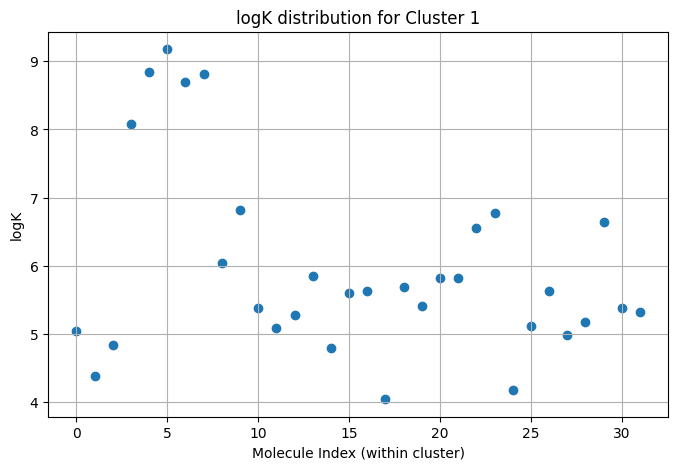

In [85]:
import matplotlib.pyplot as plt

# Select cluster
cluster_id = 1
cluster_df = df[df["Cluster"] == cluster_id].copy()

print(f"Cluster {cluster_id} size: {len(cluster_df)}")

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(range(len(cluster_df)), cluster_df["log_k"])

plt.xlabel("Molecule Index (within cluster)")
plt.ylabel("logK")
plt.title(f"logK distribution for Cluster {cluster_id}")

plt.grid(True)
plt.show()

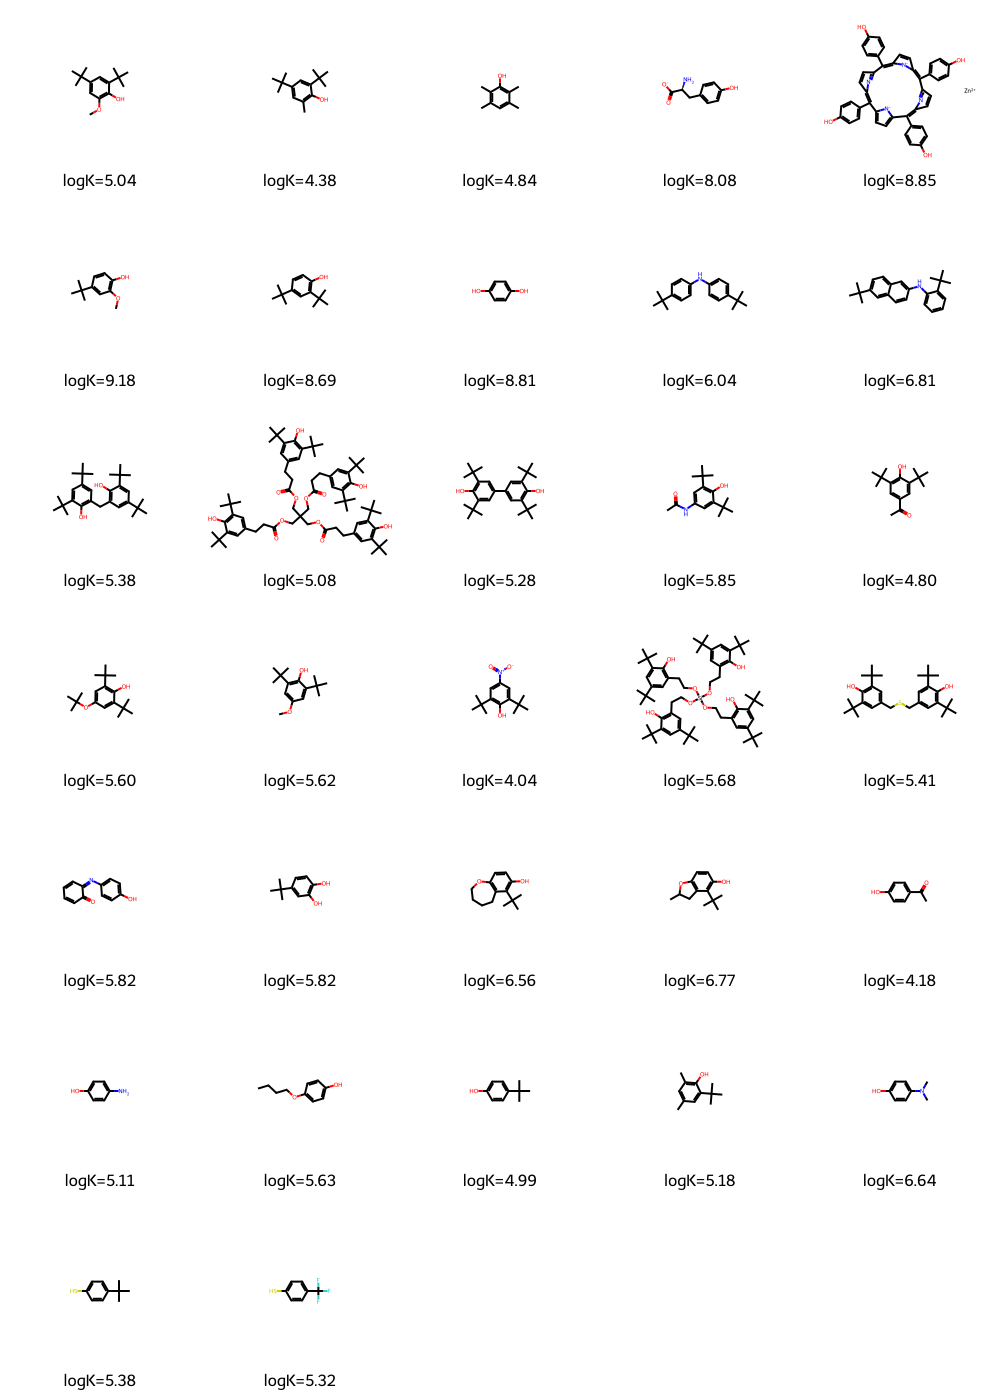

In [86]:
from rdkit import Chem
from rdkit.Chem import Draw

# Convert SMILES to RDKit Mol objects
mols = [Chem.MolFromSmiles(smi) for smi in cluster_df["SMILES"]]

# Draw grid
img = Draw.MolsToGridImage(
    mols,
    molsPerRow=5,
    subImgSize=(200, 200),
    legends=[f"logK={val:.2f}" for val in cluster_df["log_k"]]
)

img

##### SALI (Structure-Activity  Landscape Index) plot


In [87]:
cluster_df = df[df["Cluster"] == cluster_id].copy().reset_index(drop=True)
print(f"Cluster {cluster_id}: {len(cluster_df)} molecules")
print(cluster_df[["Chemical Name", "log_k"]].to_string())

Cluster 1: 32 molecules
                                             Chemical Name     log_k
0                        2,6-Di-tert-butyl-4-methoxyphenol  5.041393
1                         2,6-Di-tert-butyl-4-methylphenol  4.380211
2                                2,3,5,6-Tetramethylphenol  4.838849
3                                   Tyrosine, negative ion  8.079181
4   5,10,15,20-Tetrakis(4-hydroxyphenyl)porphinatozinc(II)  8.845098
5                              tert-Butyl-4-hydroxyanisole  9.176091
6                                  2,4-Di-tert-butylphenol  8.690196
7                                             Hydroquinone  8.812913
8                                       (4-(CH3)3CC6H4)2NH  6.041393
9                             C6H5NH-1-3,7-[(CH3)3C]2C10H5  6.812913
10                        2,2'-CH2-[4,6-[(CH3)3C]2C6H2OH]2  5.380211
11                 C-[4-(CH2)2COOCH2-2,6-[(CH3)3C]2C6H2OH]  5.079181
12                            4,4'-[2,6-[(CH3)3C]2C6H2OH]2  5.278754
13        

In [88]:
from matplotlib.colors import Normalize
from itertools import combinations
def compute_sali(cluster_df, radius=2, nBits=2048):
    mols   = [Chem.MolFromSmiles(s) for s in cluster_df["SMILES"]]
    fps    = [AllChem.GetMorganFingerprintAsBitVect(m, radius, nBits) for m in mols]
    acts   = cluster_df["log_k"].values
    names  = cluster_df["Chemical Name"].values

    records = []
    for i, j in combinations(range(len(mols)), 2):
        sim  = DataStructs.TanimotoSimilarity(fps[i], fps[j])
        dist = 1 - sim
        act_diff = abs(acts[i] - acts[j])

        # avoid division by zero (identical fingerprints)
        sali = act_diff / dist if dist > 1e-6 else np.nan

        records.append({
            "mol_i":     names[i],
            "mol_j":     names[j],
            "idx_i":     i,
            "idx_j":     j,
            "similarity": sim,
            "act_diff":  act_diff,
            "SALI":      sali,
        })

    return pd.DataFrame(records).dropna(subset=["SALI"])

sali_df = compute_sali(cluster_df)
print(sali_df.sort_values("SALI", ascending=False).head(10)
      [["mol_i","mol_j","similarity","act_diff","SALI"]])

                                 mol_i                        mol_j  \
213                       Hydroquinone                  4-NH2C6H4OH   
4    2,6-Di-tert-butyl-4-methoxyphenol  tert-Butyl-4-hydroxyanisole   
212                       Hydroquinone                4-CH3COC6H4OH   
35    2,6-Di-tert-butyl-4-methylphenol      2,4-Di-tert-butylphenol   
185            2,4-Di-tert-butylphenol         2-HO-4-(CH3)3CC6H3OH   
160        tert-Butyl-4-hydroxyanisole         2-HO-4-(CH3)3CC6H3OH   
215                       Hydroquinone              4-(CH3)3CC6H4OH   
166        tert-Butyl-4-hydroxyanisole              4-(CH3)3CC6H4OH   
191            2,4-Di-tert-butylphenol              4-(CH3)3CC6H4OH   
34    2,6-Di-tert-butyl-4-methylphenol  tert-Butyl-4-hydroxyanisole   

     similarity  act_diff      SALI  
213    0.615385  3.698970  9.617322  
4      0.531250  4.134699  8.820690  
212    0.470588  4.636822  8.758442  
35     0.500000  4.309985  8.619970  
185    0.666667  2.870652  8

[18:04:26] DEPRECATION WARNING: please use MorganGenerator
[18:04:26] DEPRECATION WARNING: please use MorganGenerator
[18:04:26] DEPRECATION WARNING: please use MorganGenerator
[18:04:26] DEPRECATION WARNING: please use MorganGenerator
[18:04:26] DEPRECATION WARNING: please use MorganGenerator
[18:04:26] DEPRECATION WARNING: please use MorganGenerator
[18:04:26] DEPRECATION WARNING: please use MorganGenerator
[18:04:26] DEPRECATION WARNING: please use MorganGenerator
[18:04:26] DEPRECATION WARNING: please use MorganGenerator
[18:04:26] DEPRECATION WARNING: please use MorganGenerator
[18:04:26] DEPRECATION WARNING: please use MorganGenerator
[18:04:26] DEPRECATION WARNING: please use MorganGenerator
[18:04:26] DEPRECATION WARNING: please use MorganGenerator
[18:04:26] DEPRECATION WARNING: please use MorganGenerator
[18:04:26] DEPRECATION WARNING: please use MorganGenerator
[18:04:26] DEPRECATION WARNING: please use MorganGenerator
[18:04:26] DEPRECATION WARNING: please use MorganGenerat

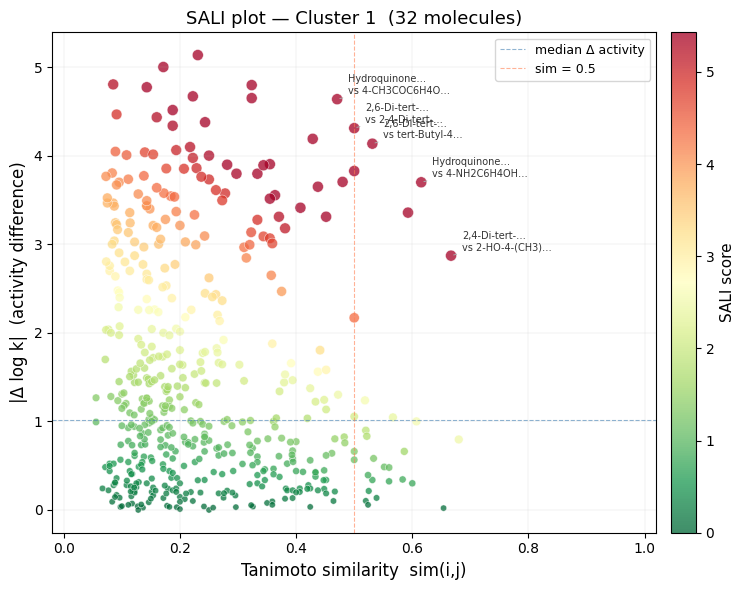

In [89]:
# ── 3. SALI scatter plot

import matplotlib.cm as cm
fig, ax = plt.subplots(figsize=(8, 6))

norm  = Normalize(vmin=sali_df["SALI"].min(), vmax=sali_df["SALI"].quantile(0.95))
cmap  = cm.RdYlGn_r    # red = high cliff, green = smooth

sc = ax.scatter(
    sali_df["similarity"],
    sali_df["act_diff"],
    c=sali_df["SALI"],
    cmap=cmap,
    norm=norm,
    s=sali_df["SALI"].clip(upper=sali_df["SALI"].quantile(0.95)) * 8 + 20,
    alpha=0.75,
    edgecolors="white",
    linewidths=0.4,
)

# annotate top 5 cliff pairs
top5 = sali_df.nlargest(5, "SALI")
for _, row in top5.iterrows():
    label = f"{row['mol_i'][:12]}…\nvs {row['mol_j'][:12]}…"
    ax.annotate(
        label,
        xy=(row["similarity"], row["act_diff"]),
        xytext=(8, 4), textcoords="offset points",
        fontsize=7, color="#333",
        arrowprops=dict(arrowstyle="-", color="#aaa", lw=0.7),
    )

cbar = plt.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label("SALI score", fontsize=11)

ax.set_xlabel("Tanimoto similarity  sim(i,j)", fontsize=12)
ax.set_ylabel("|Δ log k|  (activity difference)", fontsize=12)
ax.set_title(f"SALI plot — Cluster {cluster_id}  ({len(cluster_df)} molecules)", fontsize=13)
ax.set_xlim(-0.02, 1.02)

# cliff threshold line: high sim, high activity diff
ax.axhline(y=sali_df["act_diff"].median(), color="steelblue",
           lw=0.8, ls="--", alpha=0.6, label="median Δ activity")
ax.axvline(x=0.5, color="coral",
           lw=0.8, ls="--", alpha=0.6, label="sim = 0.5")
ax.legend(fontsize=9)
ax.grid(True, lw=0.3, alpha=0.4)

plt.tight_layout()
plt.savefig(f"sali_cluster_{cluster_id}.png", dpi=150)
plt.show()

In [90]:
# ── 4. Activity cliff summary table
threshold_sali = sali_df["SALI"].quantile(0.75)   # top 25% = cliffs
threshold_sim  = 0.5                               # structurally similar

cliffs = sali_df[
    (sali_df["SALI"] >= threshold_sali) &
    (sali_df["similarity"] >= threshold_sim)
].sort_values("SALI", ascending=False)

print(f"\n=== Activity Cliffs (SALI ≥ {threshold_sali:.2f}, sim ≥ {threshold_sim}) ===")
print(cliffs[["mol_i","mol_j","similarity","act_diff","SALI"]].to_string(index=False))


=== Activity Cliffs (SALI ≥ 2.92, sim ≥ 0.5) ===
                            mol_i                       mol_j  similarity  act_diff     SALI
                     Hydroquinone                 4-NH2C6H4OH    0.615385  3.698970 9.617322
2,6-Di-tert-butyl-4-methoxyphenol tert-Butyl-4-hydroxyanisole    0.531250  4.134699 8.820690
 2,6-Di-tert-butyl-4-methylphenol     2,4-Di-tert-butylphenol    0.500000  4.309985 8.619970
          2,4-Di-tert-butylphenol        2-HO-4-(CH3)3CC6H3OH    0.666667  2.870652 8.611956
      tert-Butyl-4-hydroxyanisole        2-HO-4-(CH3)3CC6H3OH    0.592593  3.356547 8.238798
                     Hydroquinone             4-(CH3)3CC6H4OH    0.500000  3.826142 7.652283
                     Hydroquinone             4-(CH3)2NC6H4OH    0.500000  2.169461 4.338921


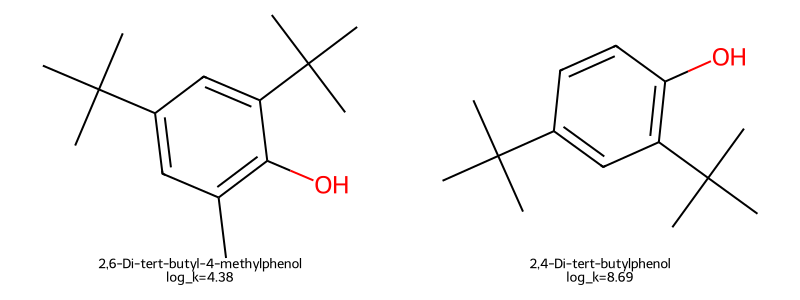


Top cliff: SALI=8.62, similarity=0.500, Δlog_k=4.31


In [70]:
# ── 5. Optional: draw the top cliff pair side by side
from rdkit.Chem import Draw
from IPython.display import display
from PIL import Image
import io

top_pair = sali_df.nlargest(1, "SALI").iloc[0]
i, j = int(top_pair["idx_i"]), int(top_pair["idx_j"])

mol_i = Chem.MolFromSmiles(cluster_df.loc[i, "SMILES"])
mol_j = Chem.MolFromSmiles(cluster_df.loc[j, "SMILES"])

img = Draw.MolsToGridImage(
    [mol_i, mol_j],
    molsPerRow=2,
    subImgSize=(400, 300),
    legends=[
        f"{cluster_df.loc[i,'Chemical Name']}\nlog_k={cluster_df.loc[i,'log_k']:.2f}",
        f"{cluster_df.loc[j,'Chemical Name']}\nlog_k={cluster_df.loc[j,'log_k']:.2f}",
    ],
)
display(img)
print(f"\nTop cliff: SALI={top_pair['SALI']:.2f}, "
      f"similarity={top_pair['similarity']:.3f}, "
      f"Δlog_k={top_pair['act_diff']:.2f}")

##### Electronic Reaction Center Plot

In [71]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import io, math

from rdkit import Chem
from rdkit.Chem import AllChem, Draw, rdPartialCharges
from rdkit.Chem.Draw import rdMolDraw2D

from PIL import Image as PILImage

## CLUSTERRR------
CLUSTER_ID = 2

cluster_df = (
    df[df["Cluster"] == CLUSTER_ID]
    .copy()
    .reset_index(drop=True)
)


In [72]:
#  Corrected Fukui f0 calculator
def compute_fukui_f0(smiles):
    """
    Approximate Fukui f0 using Gasteiger charge perturbation.

      • computes charges on neutral molecule
      • perturbs electron density globally
      • uses local charge sensitivity magnitude

    Higher f0 = MORE reactive
    Red = highly reactive
    Blue = less reactive / stable
    """

    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None, None

    mol = Chem.AddHs(mol)

    # Neutral charges
    rdPartialCharges.ComputeGasteigerCharges(mol)
    q_neutral = np.array([
        float(atom.GetProp("_GasteigerCharge"))
        for atom in mol.GetAtoms()
    ])

    q_neutral[~np.isfinite(q_neutral)] = 0.0

    # Reactivity proxy:
    # atoms with larger absolute polarization/reactive charge
    # are treated as more radical-reactive

    f0 = np.abs(q_neutral)

    # Remove hydrogens
    mol_noh = Chem.RemoveHs(mol)
    n_heavy = mol_noh.GetNumAtoms()
    f0_heavy = f0[:n_heavy]

    # Normalize
    minv = f0_heavy.min()
    maxv = f0_heavy.max()

    if (maxv - minv) > 1e-8:
        f0_norm = (f0_heavy - minv) / (maxv - minv)
    else:
        f0_norm = np.ones(n_heavy) * 0.5

    return mol_noh, f0_norm

In [73]:

#  Draw molecule with corrected coloring
def draw_fukui_molecule(mol, f0_norm, size=(450, 350)):
    """
    Red   = HIGH reactivity
    Blue  = LOW reactivity / stable
    """

    cmap = cm.RdYlBu_r

    atom_colors = {}
    atom_radii = {}

    for i, val in enumerate(f0_norm):

        rgba = cmap(val)

        atom_colors[i] = rgba[:3]

        # Larger highlight for more reactive atoms
        atom_radii[i] = 0.25 + (0.45 * val)

    drawer = rdMolDraw2D.MolDraw2DCairo(*size)

    opts = drawer.drawOptions()
    opts.addAtomIndices = False
    opts.bondLineWidth = 2

    AllChem.Compute2DCoords(mol)

    drawer.DrawMolecule(
        mol,
        highlightAtoms=list(range(mol.GetNumAtoms())),
        highlightAtomColors=atom_colors,
        highlightAtomRadii=atom_radii,
        highlightBonds=[]
    )

    drawer.FinishDrawing()

    return drawer.GetDrawingText()

In [74]:
# GRID VIEW
imgs = []
titles = []

for _, row in cluster_df.iterrows():

    mol, f0_norm = compute_fukui_f0(row["SMILES"])

    if mol is None:
        continue

    png = draw_fukui_molecule(mol, f0_norm)

    imgs.append(PILImage.open(io.BytesIO(png)))

    titles.append(
        f"{row['Chemical Name'][:24]}\nlog_k={row['log_k']:.2f}"
    )


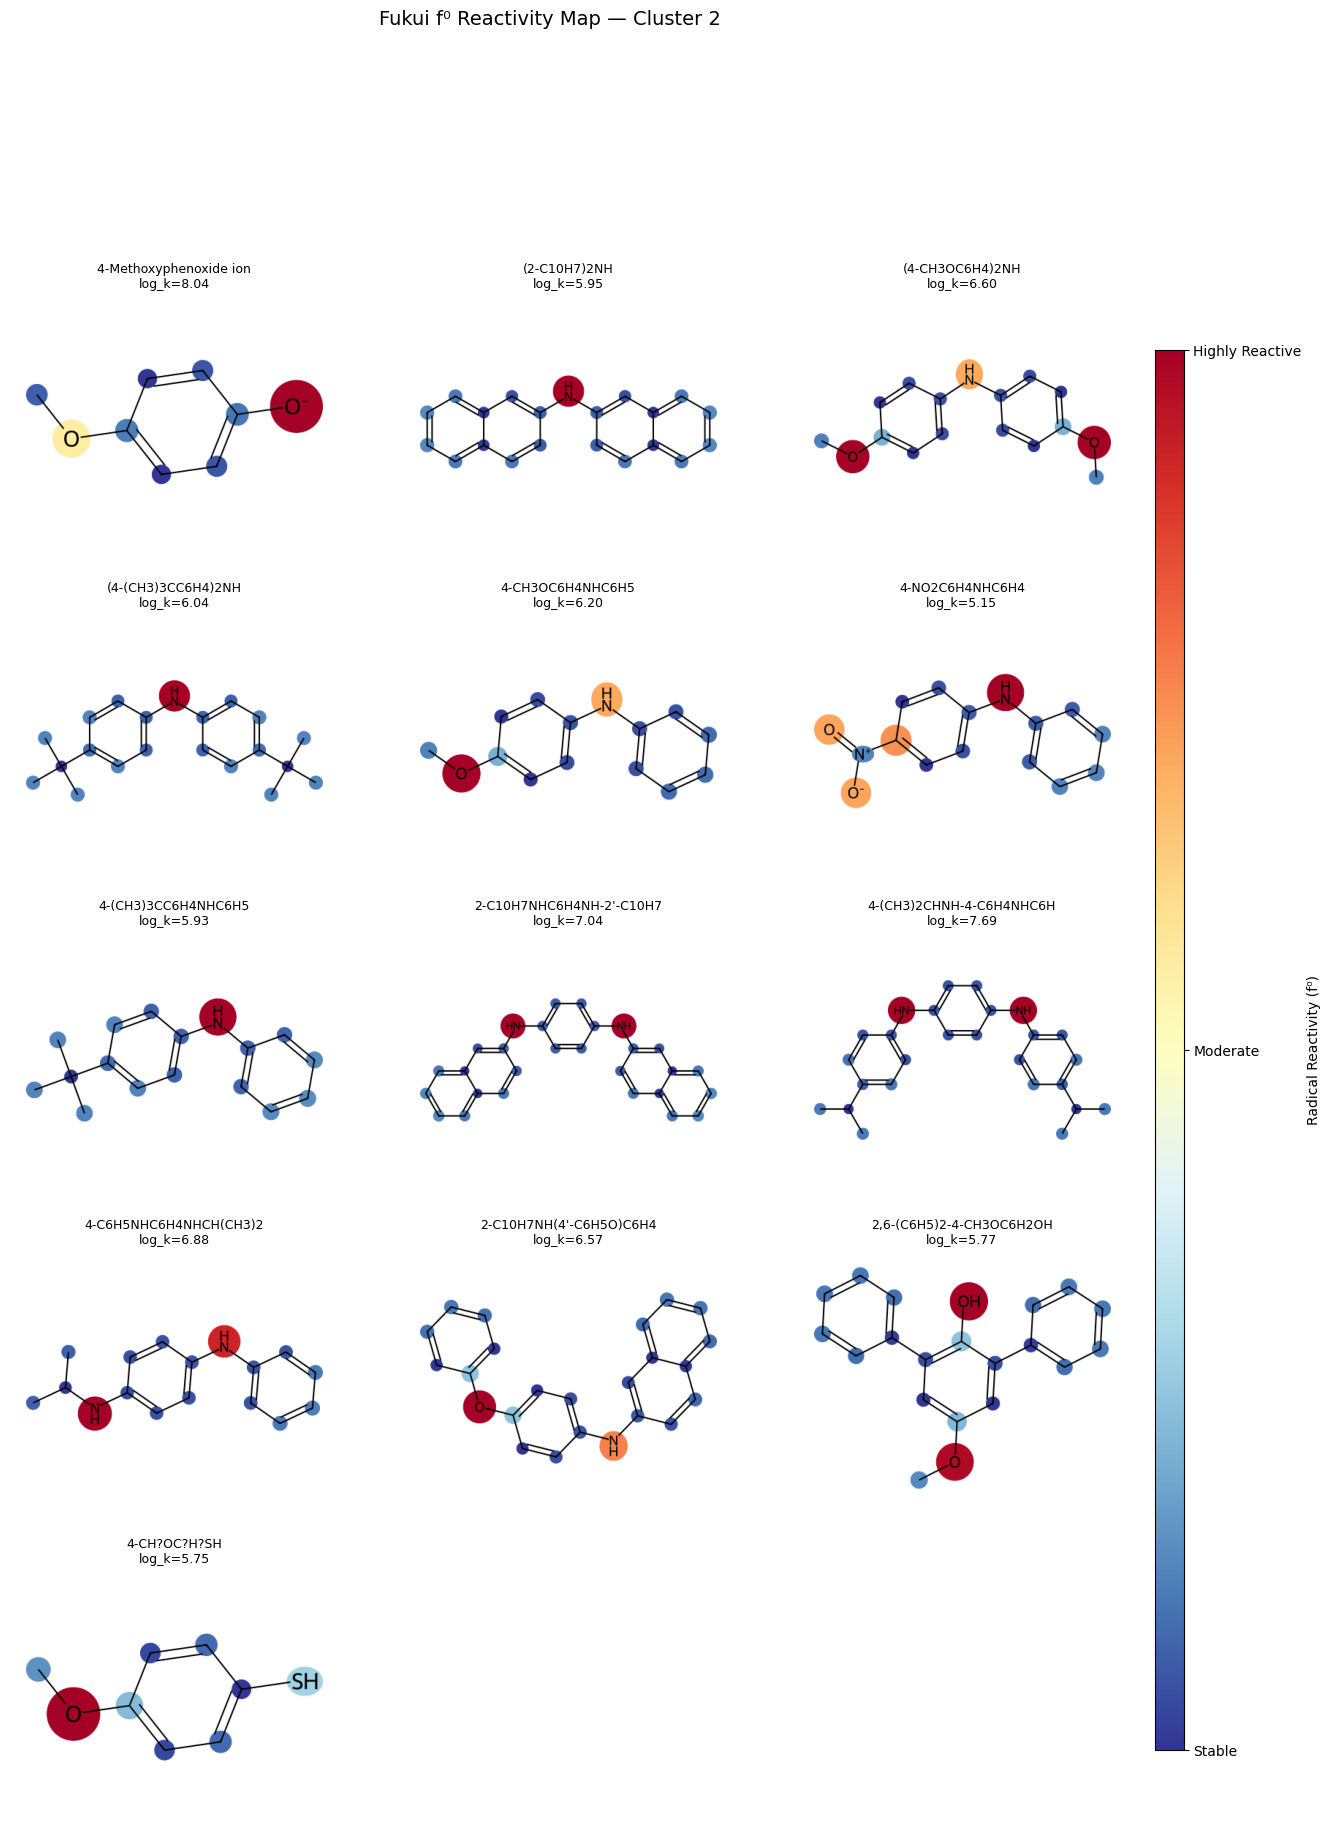

In [75]:

# ── 5. Grid plotting
n = len(imgs)

cols = min(3, n)
rows = math.ceil(n / cols)

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(cols * 4.8, rows * 4.0)
)

axes = np.array(axes).flatten()

for i, (img, title) in enumerate(zip(imgs, titles)):

    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(title, fontsize=9, pad=5)

# Hide empty panels
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

# Shared colorbar
fig.subplots_adjust(right=0.90)

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])

norm = mcolors.Normalize(vmin=0, vmax=1)

cb = fig.colorbar(
    cm.ScalarMappable(norm=norm, cmap=cm.RdYlBu_r),
    cax=cbar_ax
)

cb.set_label("Radical Reactivity (f⁰)", fontsize=10)

cb.set_ticks([0, 0.5, 1])
cb.set_ticklabels([
    "Stable",
    "Moderate",
    "Highly Reactive"
])

fig.suptitle(
    f"Fukui f⁰ Reactivity Map — Cluster {CLUSTER_ID}",
    fontsize=14,
    y=1.02
)

plt.savefig(
    f"fukui_cluster_{CLUSTER_ID}.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

### Comparing Substructures with different cluster